### Project Overview ###

**Project Objective**: This project aims to price a barrier option, specifically a Down-and-Out Call Option, on Tesla (TSLA) stock. Given TSLA's high volatility and frequent price jumps (due to earnings announcements, news, etc.), the traditional Black-Scholes model may underestimate tail risks. Therefore, this project introduces a Jump-Diffusion Model and uses Monte Carlo simulations to compare against the traditional analytical solution.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.optimize import brentq
from scipy.stats import norm

import scipy.special as sp
import math

### Part 1: Parameter Calibration

In [2]:
ticker = 'TSLA'
print(f"Downloading data for {ticker}...")
data = yf.download(ticker, start="2019-01-01", end="2024-01-01")
prices = data['Close']

# Calculate daily log returns: log(Price_t / Price_t-1)
returns = np.log(prices / prices.shift(1)).dropna()

# Calculate mean and std of the return
mean_return = returns.mean()
std_return = returns.std()

# Define threshold: outside 3 std
threshold = 3 * std_return

# Identify positive jumps and negative jumps
positive_jumps = returns[returns > (mean_return + threshold)].dropna()
negative_jumps = returns[returns < (mean_return - threshold)].dropna()
all_jumps = pd.concat([positive_jumps, negative_jumps]).sort_index()

[*********************100%***********************]  1 of 1 completed


Let
- $S_{t_1}$ be the stock price at time $t_1$.
- $S_{t_2}$ be the stock price at time $t_2$.
- $\Delta t = t_2 - t_1$.
- $r$: Risk-free interest rate.
- $\lambda$: The number of jumps per year.
- $\sigma$: The volatility of continuous part.
- $Y_i$: The log-jump size, where $Y_i \sim N(\mu_J, \delta_J^2)$.
- $\kappa$: The expected relative jump size, defined as $E[e^{Y_i} - 1] = e^{\mu_J + \frac{1}{2}\delta_J^2} - 1$. 
- $k$: Number of jumps in the interval, where $k\sim \text{Poisson}(\lambda \Delta t)$.
- $Z$: Standard Normal Distribution. 


In *Option Pricing when Underlying Stock Returns are Discontinuous (Merton 1976)*, the stock price follows this equation:$$dS_t = (r - \lambda\kappa) S_t dt + \sigma S_t dW_t + S_{t^-} d\left( \sum_{i=1}^{N_t} (e^{Y_i} - 1) \right)$$

From Ito's formula:
$$d \ln(S_t) = \left( r - \lambda\kappa - \frac{1}{2}\sigma^2 \right) dt + \sigma dW_t + \sum_{i=1}^{dN_t} Y_i.$$

Thus,$$\ln\left(\frac{S_{t_2}}{S_{t_1}}\right) = \underbrace{\left( r - \lambda\kappa - \frac{1}{2}\sigma^2 \right) \Delta t}_{\text{Drift}} + \underbrace{\sigma \sqrt{\Delta t} Z}_{\text{Diffusion}} + \underbrace{\sum_{i=1}^{k} Y_i}_{\text{Jumps}}.$$

In the later simulation, we can use$$S_{t_2} = S_{t_1} \cdot \exp \left[ \left( r - \lambda\kappa - \frac{1}{2}\sigma^2 \right) \Delta t + \sigma \sqrt{\Delta t} Z + \sum_{i=1}^{k} Y_i \right]$$

_Note: Abusive notation occurs in the math and coding parts. $dt$ is differentiation with respect to $t$ in the math part, while dt is $t_2-t_1$ in the coding part._

In [3]:
# Identify the "Normal" (Non-Jump) days
normal_days = returns[abs(returns - mean_return) <= threshold]

# Calculate the daily sigma and then annualize it
steps = 252       # Trading days
sigma = normal_days.std() * np.sqrt(252)

print(f"Calibrated Sigma (Normal Vol): {sigma.iloc[0]:.4f}")

mu_j = all_jumps.mean()
sigma_j = all_jumps.std()
lam_tsla = len(all_jumps) / len(returns) * steps
print(f"\n--- Jump Analysis for {ticker} ---")
print(f"Total trading days: {len(returns)}")
print(f"Number of identified jumps: {len(all_jumps)}")
print(f"Jump frequency (lambda): {lam_tsla:.2f} jumps per year")
print(f"Mean jump size (mu_j): {mu_j.iloc[0]:.4f}")
print(f"Jump volatility (sigma_j): {sigma_j.iloc[0]:.4f}")

Calibrated Sigma (Normal Vol): 0.5603

--- Jump Analysis for TSLA ---
Total trading days: 1257
Number of identified jumps: 23
Jump frequency (lambda): 4.61 jumps per year
Mean jump size (mu_j): -0.0338
Jump volatility (sigma_j): 0.1540


In [4]:
S0 = 399.0        # Recent TSLA Price (March 2026)
T = 1.0           # 1 Year horizon
r = 0.045         # Risk-free rate (approx. 4.5%)

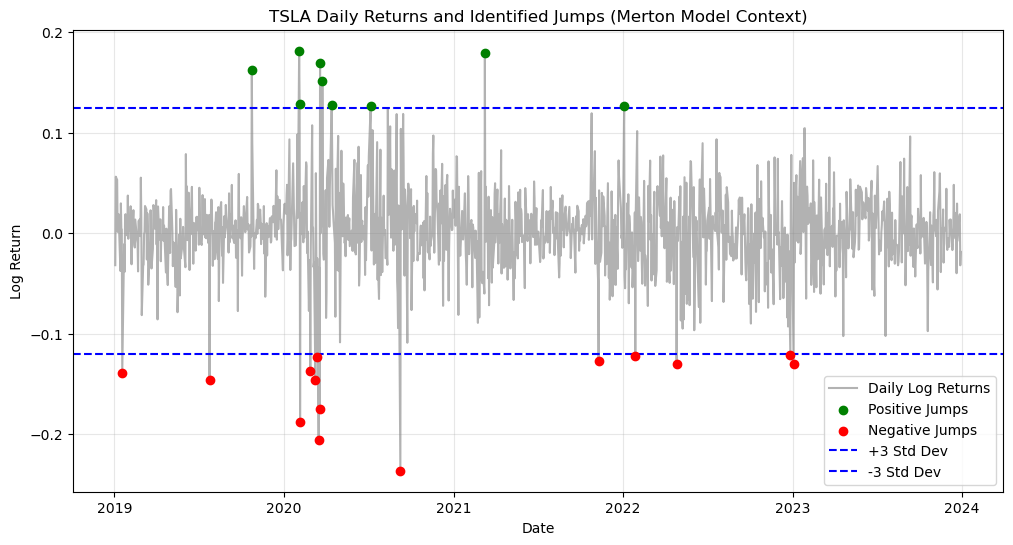


Top 5 Extreme Jumps:
Ticker          TSLA
Date                
2020-09-08  0.236518
2020-03-16  0.205522
2020-02-05  0.188450
2020-02-03  0.181445
2021-03-09  0.179327


In [5]:
plt.figure(figsize=(12, 6))
plt.plot(returns.index, returns, label='Daily Log Returns', color='gray', alpha=0.6)
plt.title(f"{ticker} Daily Returns and Identified Jumps (Merton Model Context)")

plt.scatter(positive_jumps.index, positive_jumps, color='green', label='Positive Jumps', zorder=5)
plt.scatter(negative_jumps.index, negative_jumps, color='red', label='Negative Jumps', zorder=5)

plt.axhline((mean_return + threshold).iloc[0], color='blue', linestyle='--', label='+3 Std Dev')
plt.axhline((mean_return - threshold).iloc[0], color='blue', linestyle='--', label='-3 Std Dev')

plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nTop 5 Extreme Jumps:")
print(all_jumps.abs().sort_values(by=all_jumps.columns[0],ascending=False).head(5))

### Part 2: Monte Carlo Simulation - Jump-Diffusion Model

In [6]:
np.random.seed(10)
def simulate_merton(S0, T, r, sigma, lam, mu_j, sigma_j, steps, iterations):
    dt = T / steps
    kappa = np.exp(mu_j + 0.5 * sigma_j**2) - 1
    drift = (r - 0.5 * sigma**2 - lam * kappa) * dt
    diffusion = sigma * np.sqrt(dt)

    paths = np.zeros((steps + 1, iterations))
    paths[0] = S0
    for t in range(1, steps + 1):
        Z = np.random.standard_normal(iterations)
        n_jumps = np.random.poisson(lam * dt, iterations)
        jump_sum = np.zeros(iterations)
        for i in range(iterations):
            if n_jumps[i] > 0:
                jump_sum[i] = np.random.normal(mu_j, sigma_j, n_jumps[i]).sum()
        paths[t] = paths[t-1] * np.exp(drift + diffusion * Z + jump_sum)
    return paths

/var/folders/3d/7b9r8jkn65dg832jd6xrm5480000gn/T/ipykernel_20212/1799862643.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  tsla_paths = simulate_merton(S0, T, r, float(sigma), lam_tsla, float(mu_j), float(sigma_j), steps, iterations)
/var/folders/3d/7b9r8jkn65dg832jd6xrm5480000gn/T/ipykernel_20212/1799862643.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  bs_paths = simulate_merton(S0, T, r, float(sigma), 0, float(mu_j), float(sigma_j), steps, iterations) # lambda=0


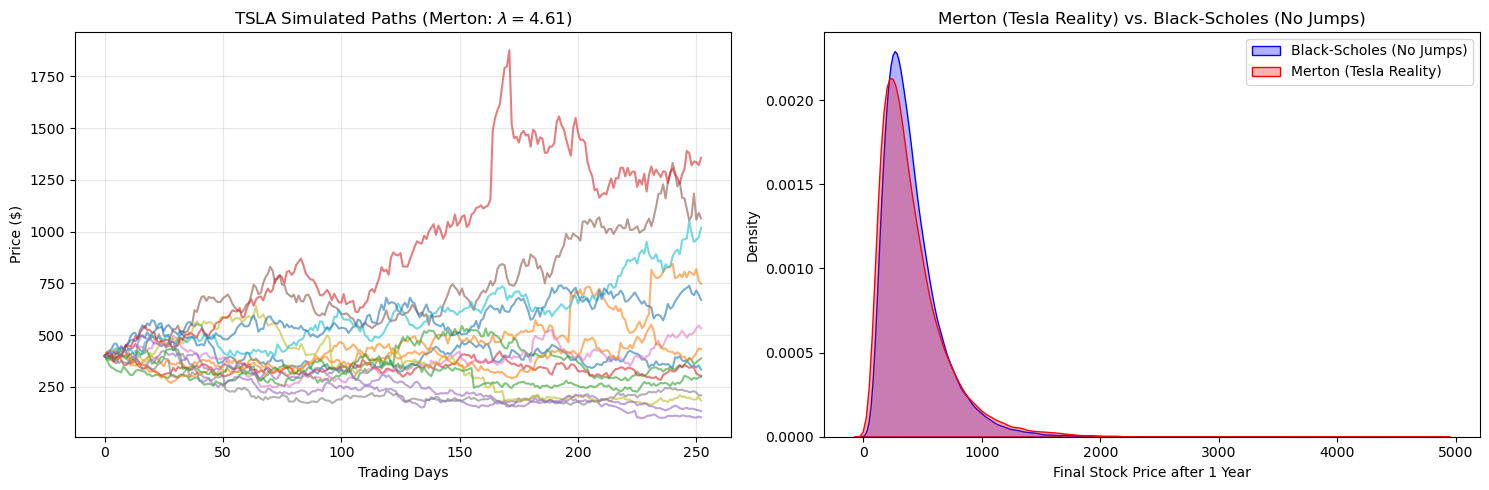

In [7]:
iterations = 50000 
tsla_paths = simulate_merton(S0, T, r, float(sigma), lam_tsla, float(mu_j), float(sigma_j), steps, iterations)
bs_paths = simulate_merton(S0, T, r, float(sigma), 0, float(mu_j), float(sigma_j), steps, iterations) # lambda=0

# --- Visualizations for your Project ---
plt.figure(figsize=(15, 5))

# Plot A: Sample Paths (Show the Jumps!)
plt.subplot(1, 2, 1)
plt.plot(tsla_paths[:, :15], alpha=0.6)
plt.title(rf"TSLA Simulated Paths (Merton: $\lambda={lam_tsla:.2f}$)")
plt.xlabel("Trading Days")
plt.ylabel("Price ($)")
plt.grid(True, alpha=0.3)

# Plot B: The "Fat Tails" Comparison (Distribution of Final Prices)
plt.subplot(1, 2, 2)
sns.kdeplot(bs_paths[-1], label="Black-Scholes (No Jumps)", fill=True, color='blue', alpha=0.3)
sns.kdeplot(tsla_paths[-1], label="Merton (Tesla Reality)", fill=True, color='red', alpha=0.3)
plt.title("Merton (Tesla Reality) vs. Black-Scholes (No Jumps)")
plt.xlabel("Final Stock Price after 1 Year")
plt.legend()

plt.tight_layout()
plt.show()

Now, we introduce a Down-and-Out call by adding a barrier to the option. If the stock price falls below $320, the option becomes void. Mathematically, the payoff of a Down-and-Out call is:$$\text{Payoff} = \max(S_T - K, 0) \times \mathbb{1}_{\{\min_{0 \leq t \leq T}(S_t) > L\}}$$

In [8]:
K = 400.0         # Strike Price
L = 320.0         # Barrier

def price_barrier_option(paths, K, L, r, T):
    iterations = paths.shape[1]
    
    # Identify which paths hit the barrier 
    hit_barrier = np.any(paths <= L, axis=0)
    
    # Calculate Payoffs at Maturity (T)
    final_prices = paths[-1]
    payoffs = np.maximum(final_prices - K, 0)
    
    # Apply the "Knock-Out" rule
    # If hit_barrier is True, payoff is 0
    payoffs[hit_barrier] = 0
    
    # Average and Discount back to today
    option_price = np.mean(payoffs) * np.exp(-r * T)
    
    # Return both the price and the 'survival rate' for the graphs
    survival_rate = (1 - np.mean(hit_barrier)) * 100
    return option_price, survival_rate, hit_barrier
merton_price, merton_survival, merton_hits = price_barrier_option(tsla_paths, K, L, r, T)
bs_price, bs_survival, bs_hits = price_barrier_option(bs_paths, K, L, r, T)

print(f"--- Results for TSLA Barrier Option ---")
print(f"Merton Price (with Jumps): ${merton_price:.2f} | Survival Rate: {merton_survival:.1f}%")
print(f"BS Price (No Jumps):       ${bs_price:.2f} | Survival Rate: {bs_survival:.1f}%")

--- Results for TSLA Barrier Option ---
Merton Price (with Jumps): $76.09 | Survival Rate: 24.2%
BS Price (No Jumps):       $70.98 | Survival Rate: 27.5%


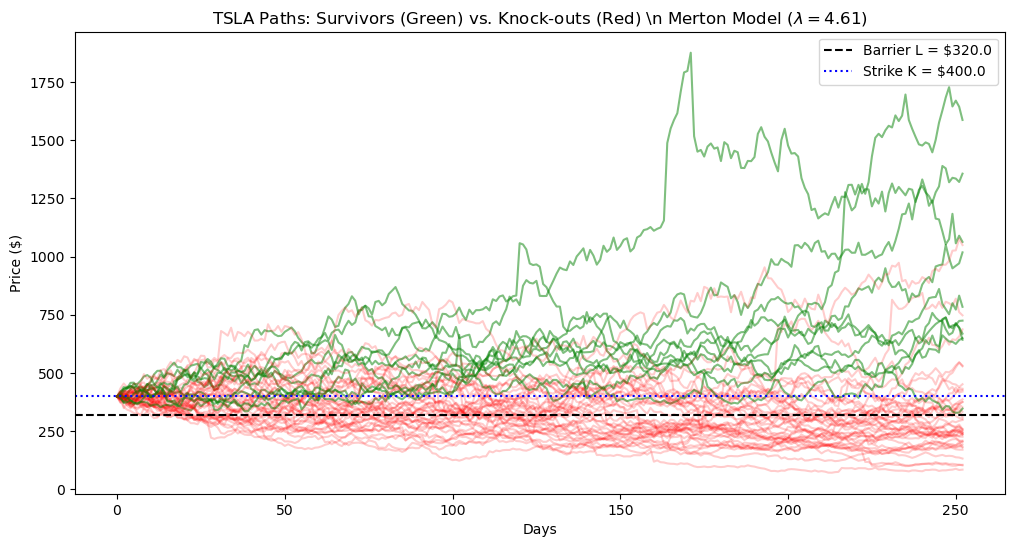

In [9]:
plt.figure(figsize=(12, 6))

# Plot only the first 50 paths to keep it clean
for i in range(50):
    color = 'green' if not merton_hits[i] else 'red'
    alpha = 0.5 if not merton_hits[i] else 0.2
    plt.plot(tsla_paths[:, i], color=color, alpha=alpha)

plt.axhline(y=L, color='black', linestyle='--', label=f'Barrier L = ${L}')
plt.axhline(y=K, color='blue', linestyle=':', label=f'Strike K = ${K}')
plt.title(rf"TSLA Paths: Survivors (Green) vs. Knock-outs (Red) \n Merton Model ($\lambda=4.61$)")
plt.xlabel("Days")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

### Part 3: Mathematical and Simulated Functions for the Barrier Option (DOC)

In [10]:
# Standard Black-Scholes Call formula
def bs_call_price(S, K, T, r, sigma):
    if sigma <= 0 or T <= 0: return max(0, S - K)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


`analytical_doc_price`：
For a Down-and-Out Call (DOC), the option remains active only if the stock price $S_t$ never touches the barrier $L$ during the life of the option ($S_t > L$ for all $t \in [0, T]$). The value is derived by subtracting a "reflection" term from a standard vanilla call:$$V_{DOC} = V_{vanilla} - V_{reflection}$$
The reflection term represents the value of the paths that "knock out" by touching $L$. This is calculated by mirroring the payoff across the barrier line. The closed-form solution is:$$V_{DOC} = S_0 \Phi(d_1) - Ke^{-rT}\Phi(d_2) - S_0(L/S_0)^{2\eta} \Phi(y) + Ke^{-rT}(L/S_0)^{2\eta-2} \Phi(y - \sigma\sqrt{T})$$Where:$\eta = \frac{r + \frac{1}{2}\sigma^2}{\sigma^2}$ (The drift-to-variance ratio).$y$ is the adjusted distance to the barrier in a reflected state.

`merton_analytical_doc_price`：Also in Merton 1976, the option price $V_{Merton}$ is an infinite sum of Black-Scholes prices, weighted by the probability of $n$ jumps occurring (Poisson distribution):$$V_{Merton} = \sum_{n=0}^{\infty} \frac{e^{-\lambda' T}(\lambda' T)^n}{n!} V_{BS}(S, K, T, \sigma_n, r_n),$$
where  $\lambda' = \lambda(1+\kappa)$, the adjusted volatility $\sigma_n$ and rate $r_n$ are:$$\sigma_n = \sqrt{\sigma^2 + n \frac{\gamma^2}{T}}, \quad r_n = r - \lambda(e^{\mu_j + \gamma^2/2} - 1) + \frac{n \ln(1+k)}{T}$$.



In [11]:
def analytical_doc_price(S, K, L, T, r, sigma):
    """
    Standard Black-Scholes Analytical Price for a Down-and-Out Call (DOC).
    This function has 6 parameters and NO jumps.
    """
    if S <= L: return 0.0 
    
    bs_lambda = (r + 0.5 * sigma**2) / sigma**2
    y = np.log(L**2 / (S * K)) / (sigma * np.sqrt(T)) + bs_lambda * sigma * np.sqrt(T)
    
    standard_call = bs_call_price(S, K, T, r, sigma)
    
    y2 = np.log(L / S) / (sigma * np.sqrt(T)) + bs_lambda * sigma * np.sqrt(T)
    y_reflected = (L / S)**(2 * bs_lambda - 2) * (L**2 / S * norm.cdf(y) - K * np.exp(-r * T) * norm.cdf(y - sigma * np.sqrt(T)))

    price = standard_call - y_reflected
    
    return max(0, price)



def merton_analytical_doc_price(S0, K, L, T, r, sigma, lambda_j, mu_j, sigma_j):
    # 1. Calculate k (the expected jump size)
    k = math.exp(mu_j + 0.5 * sigma_j**2) - 1
    
    # 2. Calculate the risk-neutral intensity (Adjusted Lambda)
    # This is the 'lamb' we discussed earlier
    lambda_prime = lambda_j * (1 + k)
    
    # 3. Base drift adjustment
    r_adj = r - lambda_j * k
    
    total_price = 0
    # Summing the first 50 possible jump scenarios
    for n in range(50):
        # Calculate Modified Volatility and Rate for 'n' jumps
        sigma_n = math.sqrt(sigma**2 + n * sigma_j**2 / T)
        r_n = r_adj + n * math.log(1 + k) / T
        
        # Calculate the probability (weight) of exactly 'n' jumps happening
        weight = (math.exp(-lambda_prime * T) * (lambda_prime * T)**n) / math.factorial(n)
        
        # NESTED CALL: We feed the scenario parameters into your 6-parameter BS function
        # Order: S0, K, L, T, rate, volatility
        bs_barrier_price = analytical_doc_price(S0, K, L, T, r_n, sigma_n)
        
        # Add this scenario's value to the total
        total_price += weight * bs_barrier_price
        
    return total_price

In [12]:
def mc_doc_brownian_bridge(S, K, L, T, r, sigma, lambda_j=0, mu_j=0, sigma_j=0, num_paths=100000, num_steps=252):
    """
    Prices Down-and-Out Call using Monte Carlo with a Brownian Bridge 
    to correct for discrete sampling error.
    """
    if S <= L: return 0.0
        
    dt = T / num_steps
    paths = np.zeros((num_paths, num_steps + 1))
    paths[:, 0] = S
    
    k = np.exp(mu_j + 0.5 * sigma_j**2) - 1 if lambda_j > 0 else 0
    drift = (r - 0.5 * sigma**2 - lambda_j * k) * dt
    
    # Boolean array to track which paths have NOT hit the barrier
    alive = np.ones(num_paths, dtype=bool)
    
    for t in range(1, num_steps + 1):
        Z = np.random.standard_normal(num_paths)
        diffusion = drift + sigma * np.sqrt(dt) * Z
        
        if lambda_j > 0:
            N = np.random.poisson(lambda_j * dt, num_paths) 
            J = N * np.random.normal(mu_j, sigma_j, num_paths)
        else:
            J = 0
            
        paths[:, t] = paths[:, t-1] * np.exp(diffusion + J)
        
        # 1. Standard Discrete Check (Did it close below barrier?)
        hit_end_of_day = paths[:, t] <= L
        alive[hit_end_of_day] = False
        
        # 2. Brownian Bridge Continuous Check (Did it hit intraday?)
        # We only calculate this for paths that are still alive
        active_indices = np.where(alive)[0]
        
        if len(active_indices) > 0:
            S_prev = paths[active_indices, t-1]
            S_curr = paths[active_indices, t]
            
            # Probability of hitting the barrier between t-1 and t
            # P(hit) = exp(-2 * ln(S_prev/L) * ln(S_curr/L) / (sigma^2 * dt))
            prob_hit = np.exp(-2 * np.log(S_prev / L) * np.log(S_curr / L) / (sigma**2 * dt))
            
            # Draw a random number for each active path. If U < prob_hit, it knocked out intraday.
            U = np.random.uniform(0, 1, size=len(active_indices))
            knocked_out_intraday = U < prob_hit
            
            # Update the main 'alive' tracking array
            failed_paths = active_indices[knocked_out_intraday]
            alive[failed_paths] = False

    # Calculate Payoffs (Only for paths still marked as 'alive')
    payoffs = np.zeros(num_paths)
    surviving_indices = np.where(alive & (paths[:, -1] > K))[0]
    payoffs[surviving_indices] = paths[surviving_indices, -1] - K
    
    return np.mean(payoffs) * np.exp(-r * T)


### Part 4: Risk Metrics (Greeks)
Since Greeks represent the sensitivity of the option price $V$ to various inputs, they are the terms in a Taylor Series Expansion mathematically:
$$dV = \underbrace{\frac{\partial V}{\partial S}}_{\text{Delta } \Delta} dS + \frac{1}{2}\underbrace{\frac{\partial^2 V}{\partial S^2}}_{\text{Gamma } \Gamma} dS^2 + \underbrace{\frac{\partial V}{\partial t}}_{\text{Theta } \Theta} dt + \underbrace{\frac{\partial V}{\partial \sigma}}_{\text{Vega } \nu} d\sigma + \dots$$

Let $\omega_n(\tau) = \frac{e^{-\lambda' \tau}(\lambda' \tau)^n}{n!}$ be the Poisson weight for $n$ jumps. The Merton Greeks are:

#### Delta ($\Delta$) — Price Sensitivity ####
$$\Delta_{Merton} = \frac{\partial V_{Merton}}{\partial S} = \sum_{n=0}^{\infty} \omega_n(\tau) \cdot \Delta_{BS}(S, \sigma_n, r_n),$$where $\Delta_{BS} = N(d_1^{(n)}).$$

#### Gamma ($\Gamma$) — Delta Sensitivity (Curvature) ####
$$\Gamma_{Merton} = \frac{\partial^2 V_{Merton}}{\partial S^2} = \sum_{n=0}^{\infty} \omega_n(\tau) \cdot \Gamma_{BS}(S, \sigma_n, r_n),$$
where $\Gamma_{BS} = \frac{N'(d_1^{(n)})}{S \sigma_n \sqrt{\tau}}$.

#### Vega ($\nu$) — Volatility Sensitivity ####
$$\nu_{Merton} = \frac{\partial V_{Merton}}{\partial \sigma} = \sum_{n=0}^{\infty} \omega_n(\tau) \cdot \text{Vega}_{BS}(S, \sigma_n, r_n) \cdot \left( \frac{\sigma}{\sigma_n} \right),$$
where $\text{Vega}_{BS} = S\sqrt{\tau}N'(d_1^{(n)})$.

#### Theta ($\Theta$) — Time Decay ####
$$\Theta_{Merton} = -\frac{\partial V_{Merton}}{\partial \tau} = \sum_{n=0}^{\infty} \left[ \omega_n(\tau) \cdot \Theta_{BS}(n) + V_{BS}(n) \cdot \frac{\partial \omega_n}{\partial \tau} \right],$$
where $\frac{\partial \omega_n}{\partial \tau} = \lambda'(\omega_{n-1} - \omega_n)$. 

In [13]:
def calculate_greeks(S, K, T, r, sigma, lamb, mu_j, sigma_j, L):
    h_s = 1.0       
    h_sigma = 0.001 
    h_t = 1/365     

    # 1. Price
    v_mid = merton_analytical_doc_price(S, K, L, T, r, sigma, lamb, mu_j, sigma_j)

    # 2. Delta & Gamma 
    v_s_plus = merton_analytical_doc_price(S + h_s, K, L, T, r, sigma, lamb, mu_j, sigma_j)
    v_s_minus = merton_analytical_doc_price(S - h_s, K, L, T, r, sigma, lamb, mu_j, sigma_j)
    delta = (v_s_plus - v_s_minus) / (2 * h_s)
    gamma = (v_s_plus - 2 * v_mid + v_s_minus) / (h_s**2)

    # 3. Vega (dV/dsigma)
    v_sig_plus = merton_analytical_doc_price(S, K, L, T, r, sigma + h_sigma, lamb, mu_j, sigma_j)
    v_sig_minus = merton_analytical_doc_price(S, K, L, T, r, sigma - h_sigma, lamb, mu_j, sigma_j)
    vega = (v_sig_plus - v_sig_minus) / (2 * h_sigma)
    vega_1pct = vega / 100 

    # 4. Theta (dV/dt)
    if T > h_t:
        v_t_minus = merton_analytical_doc_price(S, K, L, T - h_t, r, sigma, lamb, mu_j, sigma_j)
        theta_daily = (v_t_minus - v_mid) 
    else:
        theta_daily = 0 

    return {
        "Price": v_mid,
        "Delta": delta,
        "Gamma": gamma,
        "Vega_1%": vega_1pct,
        "Theta_Daily": theta_daily
    }

In [14]:
params = {
    "S": 399, "K": 400, "T": 1.0, "r": 0.045, 
    "sigma": 0.5603, "lamb": 4.61, "mu_j": -0.0338, "sigma_j": 0.1540, "L": 320
}

greeks = calculate_greeks(**params)
print(f"Option Price: {greeks['Price']:.2f}")
print(f"Delta (Δ): {greeks['Delta']:.5f}")
print(f"Gamma (Γ): {greeks['Gamma']:.5f}")
print(f"Vega (𝞶): {greeks['Vega_1%']:.5f}")
print(f"Theta (Θ): {greeks['Theta_Daily']:.5f}")

Option Price: 69.59
Delta (Δ): 0.87294
Gamma (Γ): -0.00002
Vega (𝞶): 0.21108
Theta (Θ): -0.03703


/var/folders/3d/7b9r8jkn65dg832jd6xrm5480000gn/T/ipykernel_20212/2537233128.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  k = math.exp(mu_j + 0.5 * sigma_j**2) - 1
/var/folders/3d/7b9r8jkn65dg832jd6xrm5480000gn/T/ipykernel_20212/2537233128.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma_n = math.sqrt(sigma**2 + n * sigma_j**2 / T)


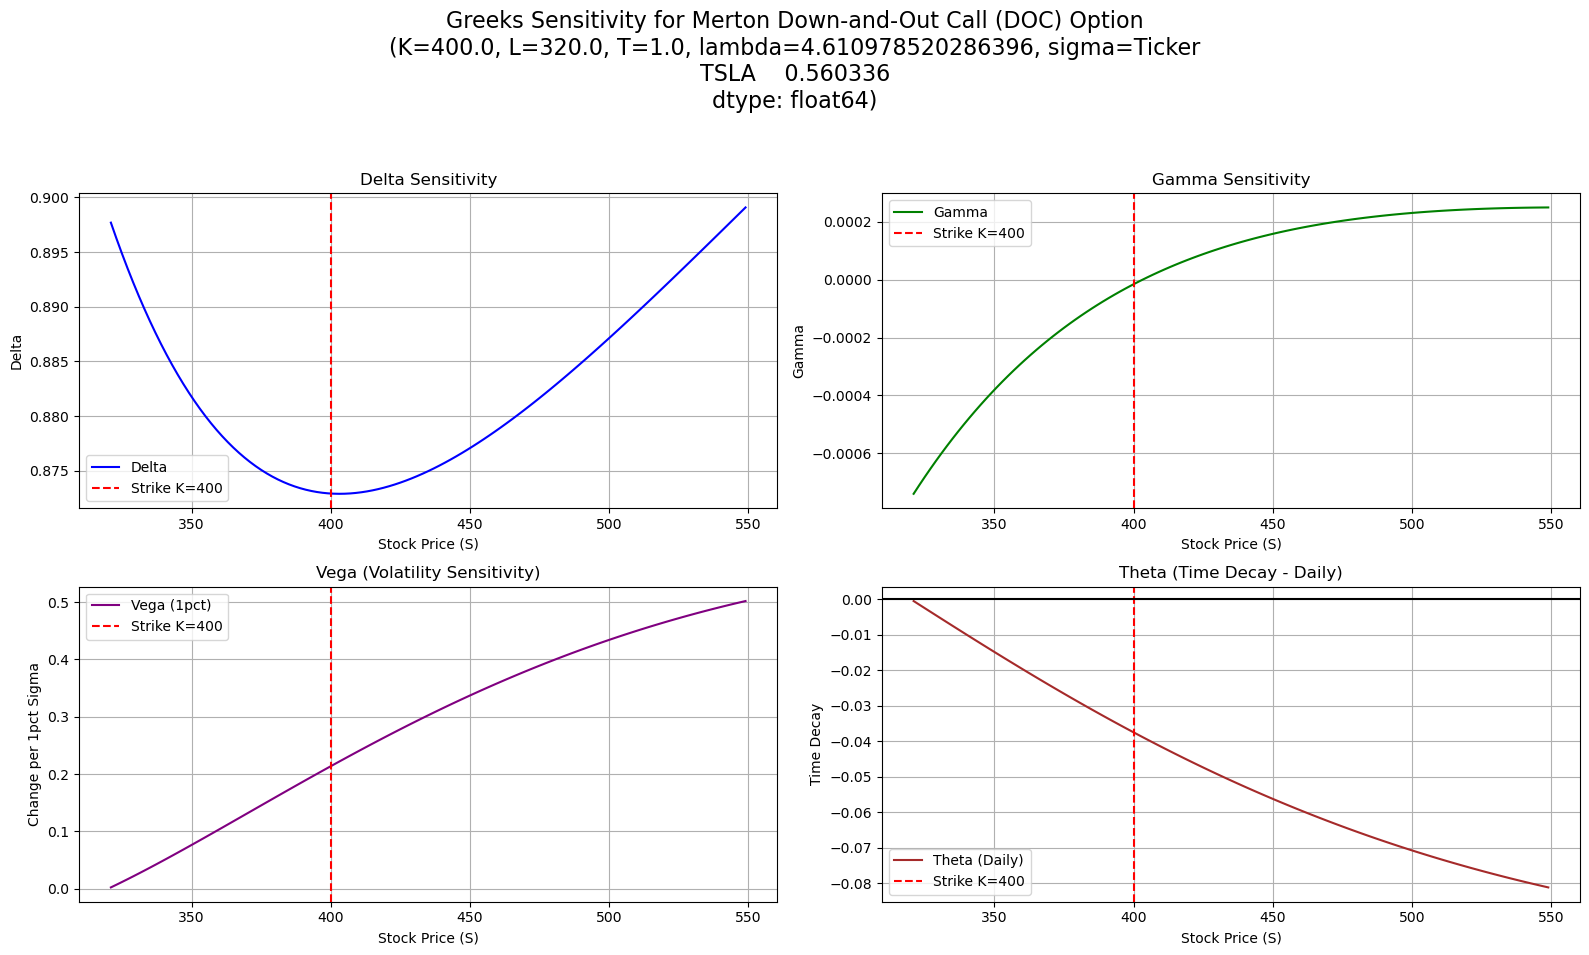

In [15]:
s_range = np.arange(321.0, 550.0, 2.0)

deltas = []
gammas = []
vegas = []
thetas = []

for S in s_range:
    greeks = calculate_greeks(S, K, T, r, sigma, lam_tsla, mu_j, sigma_j, L)
    deltas.append(greeks["Delta"])
    gammas.append(greeks["Gamma"])
    vegas.append(greeks["Vega_1%"])
    thetas.append(greeks["Theta_Daily"])


fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"Greeks Sensitivity for Merton Down-and-Out Call (DOC) Option\n"
             f"(K={K}, L={L}, T={T}, lambda={lam_tsla}, sigma={sigma})", fontsize=16)

# 1: Delta (dV/dS)
axs[0, 0].plot(s_range, deltas, label='Delta', color='blue')
axs[0, 0].set_title("Delta Sensitivity")
axs[0, 0].set_ylabel("Delta")
axs[0, 0].set_xlabel("Stock Price (S)")
axs[0, 0].grid(True)
axs[0, 0].axvline(x=K, color='r', linestyle='--', label='Strike K=400')
axs[0, 0].legend()

# 2: Gamma (d2V/dS2)
axs[0, 1].plot(s_range, gammas, label='Gamma', color='green')
axs[0, 1].set_title("Gamma Sensitivity")
axs[0, 1].set_ylabel("Gamma")
axs[0, 1].set_xlabel("Stock Price (S)")
axs[0, 1].grid(True)
axs[0, 1].axvline(x=K, color='r', linestyle='--', label='Strike K=400')
axs[0, 1].legend()

# 3: Vega 1% (dV/dsigma_1pct)
axs[1, 0].plot(s_range, vegas, label='Vega (1pct)', color='purple')
axs[1, 0].set_title("Vega (Volatility Sensitivity)")
axs[1, 0].set_ylabel("Change per 1pct Sigma")
axs[1, 0].set_xlabel("Stock Price (S)")
axs[1, 0].grid(True)
axs[1, 0].axvline(x=K, color='r', linestyle='--', label='Strike K=400')
axs[1, 0].legend()

# 4: Theta Daily (dV/dt_daily)
axs[1, 1].plot(s_range, thetas, label='Theta (Daily)', color='brown')
axs[1, 1].set_title("Theta (Time Decay - Daily)")
axs[1, 1].set_ylabel("Time Decay")
axs[1, 1].set_xlabel("Stock Price (S)")
axs[1, 1].grid(True)
axs[1, 1].axvline(x=K, color='r', linestyle='--', label='Strike K=400')
axs[1, 1].axhline(y=0, color='k', linestyle='-') 
axs[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Part 5: Comparison of Analytical and Simulated Barrier Option Price

In [16]:
sigma = 0.5603
lamb = 4.61
mu_j = -0.0338
sigma_j = 0.1540

exact_price = analytical_doc_price(S0, K, L, T, r, sigma)

sim_price = mc_doc_brownian_bridge(S0, K, L, T, r, sigma, lambda_j=0)

print(f"-"*20,"Jumps are disabled","-"*20)
print(f"Exact Analytical Price:  ${exact_price:.4f}")
print(f"Brownian Bridge MC:      ${sim_price:.4f}")
print(f"Difference:              ${abs(exact_price - sim_price):.4f}")

print(f"-"*20,"With 4.61 jumps every year","-"*20)
exact_price = merton_analytical_doc_price(S0, K, L, T, r, sigma, lamb, mu_j, sigma_j)
print(f"Exact Analytical Price:  ${exact_price:.4f}")

sim_price = mc_doc_brownian_bridge(S0, K, L, T, r, sigma, lambda_j=lamb, mu_j=mu_j, sigma_j=sigma_j)
print(f"Brownian Bridge MC:      ${sim_price:.4f}")
print(f"Difference:              ${abs(exact_price - sim_price):.4f}")


-------------------- Jumps are disabled --------------------
Exact Analytical Price:  $66.6030
Brownian Bridge MC:      $66.6017
Difference:              $0.0013
-------------------- With 4.61 jumps every year --------------------
Exact Analytical Price:  $69.5939
Brownian Bridge MC:      $73.0673
Difference:              $3.4734


In [17]:
# compute iv
def calculate_iv(market_price, S, K, T, r):
    objective = lambda sigma: bs_call_price(S, K, T, r, sigma) - market_price
    return brentq(objective, 1e-4, 5.0)

iv_equivalent = calculate_iv(merton_price, S0, K, 1, r)
print(f"Implied volatility based on the merton price: {iv_equivalent:.2%}")

Implied volatility based on the merton price: 43.63%


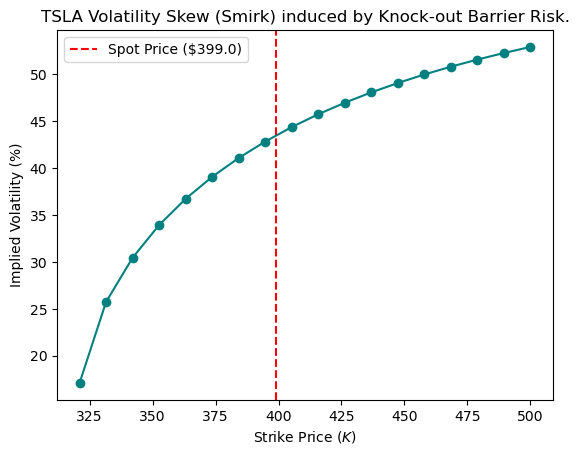

In [18]:
# Define a range of strikes (e.g., from $300 to $500)
strike_range = np.linspace(300, 500, 20) 
merton_ivs = []

for k in strike_range:
    # STEP A: Use your existing function to price the option at this strike
    # We reuse the same tsla_paths you already simulated
    m_price, _, _ = price_barrier_option(tsla_paths, k, L, r, T)
    
    # STEP B: Use your existing calculate_iv function 
    # This finds the "BS-equivalent" IV for that Merton price
    try:
        iv = calculate_iv(m_price, S0, k, T, r)
        merton_ivs.append(iv * 100) 
    except:
        merton_ivs.append(None) # Handle cases where the solver fails

# Plot the results
import matplotlib.pyplot as plt
plt.plot(strike_range, merton_ivs, 'o-', color='teal')
plt.axvline(S0, color='red', linestyle='--', label=f'Spot Price (${S0})')
plt.xlabel("Strike Price ($K$)")
plt.ylabel("Implied Volatility (%)")
plt.title("TSLA Volatility Skew (Smirk) induced by Knock-out Barrier Risk.")
plt.legend()
plt.show()